<a href="https://colab.research.google.com/github/programadorarocio/AA1-TUIA-2026C1-Diez-Duvia-Quispe/blob/main/AA2_TP1_PROBLEMA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°1 — Redes Neuronales Feed Forward y Convolucionales
## Problema 3: Regresión

### Objetivo
Construir un modelo de red neuronal que prediga el valor numérico de la rentabilidad (`Profit`) de una transacción comercial a partir de las características del pedido.

### Descripción del Dataset
El dataset cuenta con **9,994 transacciones** y **21 características**, estructuradas de la siguiente manera:


| Característica | Tipo | Descripción |
| :--- | :--- | :--- |
| **Variable Objetivo** | | |
| `Profit` | Numérico (Float) | Beneficio neto de la venta. Puede ser negativo (pérdida) o positivo (ganancia). |
| **Identificadores de transacción (no predictivos)** | | |
| `Row ID` | Entero | Identificador secuencial. |
| `Order ID` | Categórico | ID único de pedido. |
| `Customer ID` | Categórico | ID de cliente. Alta cardinalidad; evaluar si incluir. |
| **Variables temporales** | | |
| `Order Date` | Fecha (Cadena) | Fecha del pedido. Extraer año, mes, día y trimestre. |
| `Ship Date` | Fecha (Cadena) | Fecha de envío. Útil para calcular la demora. |
| **Variables de envío y logística** | | |
| `Ship Mode` | Categórico | Método de envío. |
| **Demografía del cliente** | | |
| `Customer Name` | Categórico | Nombre del cliente. |
| `Segment` | Categórico | Segmento de mercado. |
| **Variables geográficas** | | |
| `Country` | Categórico | Constante en este dataset; poco informativo. |
| `Region` | Categórico | Región geográfica. |
| `State` | Categórico | Cardinalidad media. |
| `City` | Categórico | Alta cardinalidad. Evaluar tratamiento. |
| `Postal Code` | Entero | Alta cardinalidad. Evaluar si eliminar. |
| **Variables de producto** | | |
| `Category` | Categórico | Categoría principal del producto. |
| `Sub-Category` | Categórico | Subcategoría del producto. |
| `Product ID` | Categórico | ID de producto. Evaluar codificación. |
| `Product Name` | Categórico | Redundante con categoría y subcategoría. Normalmente eliminar. |
| **Detalles de la transacción (predictores principales)** | | |
| `Sales` | Numérico (Float) | Ingresos totales de la venta. |
| `Quantity` | Entero | Número de artículos pedidos. |
| `Discount` | Numérico (Float) | Tasa de descuento aplicada. Predictor crítico. |

# Configuración del entorno

Se importan las librerías necesarias

In [50]:
import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

## Carga e Inspección Estructural del Dataset

In [2]:
!gdown 1oUurTJbvae_AF-K_mgfXf1ObcK3Uqa0t

Downloading...
From: https://drive.google.com/uc?id=1oUurTJbvae_AF-K_mgfXf1ObcK3Uqa0t
To: /content/Sample - Superstore.csv
100% 2.29M/2.29M [00:00<00:00, 147MB/s]


In [3]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')

# PUNTO 1 - ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Información general

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Visualización de datos

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

En la información inicial podemos observar que hay variables que necesitan cambiar la configuración de tipo de datos.

## Limpieza inicial

In [6]:
# Convertimos date a datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

Separación de Variables

In [7]:
# Separación de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (6): ['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']
Variables categoricas (13): ['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']


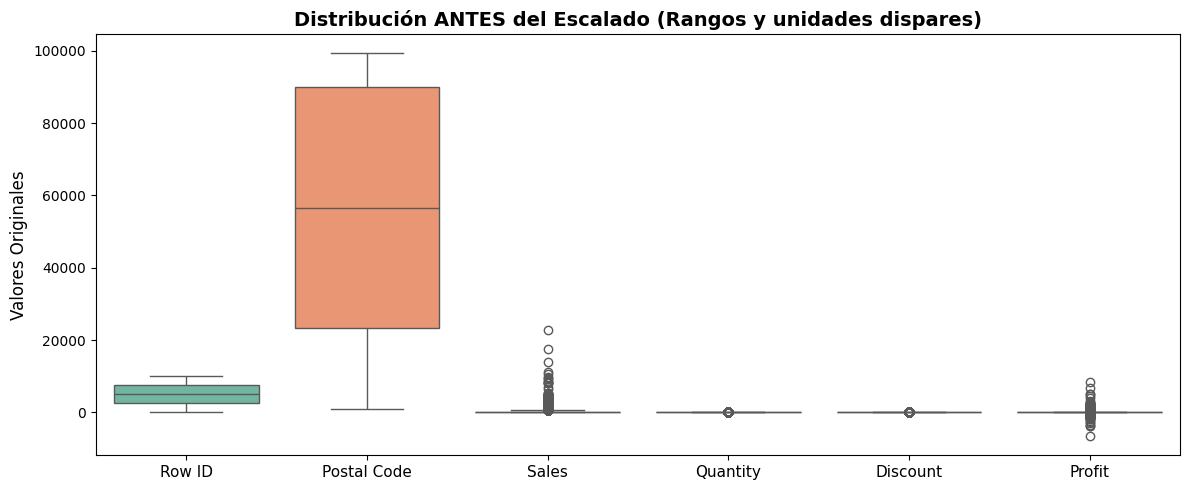

In [8]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[cols_numericas], palette="Set2")
plt.title(
    "Distribución ANTES del Escalado (Rangos y unidades dispares)",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Valores Originales", fontsize=12)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()



Se observa que las variables presentan escalas considerablemente diferentes. En particular, Postal Code presenta valores numéricamente elevados; sin embargo, esta variable representa un código geográfico y no una magnitud continua, por lo que su amplitud en el boxplot no debe interpretarse como mayor variabilidad o importancia predictiva.

In [9]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [10]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 100)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
Row ID,4997.500000,4997.5000,2885.163629,57.732139,1.000,2499.25000,4997.5000,7495.750,9994.000,0.000000,-1.200000
Postal Code,55190.379428,56430.5000,32063.693350,58.096526,1040.000,23223.00000,56430.5000,90008.000,99301.000,-0.128526,-1.493020
Sales,229.858001,54.4900,623.245101,271.143531,0.444,17.28000,54.4900,209.940,22638.480,12.972752,305.311753
Quantity,3.789574,3.0000,2.225110,58.716622,1.000,2.00000,3.0000,5.000,14.000,1.278545,1.991889
Discount,0.156203,0.2000,0.206452,132.169251,0.000,0.00000,0.2000,0.200,0.800,1.684295,2.409546
Profit,28.656896,8.6665,234.260108,817.465036,-6599.978,1.72875,8.6665,29.364,8399.976,7.561432,397.188515


In [11]:
print('Interpretación del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretación del Sesgo y Curtosis:
    Row ID: sesgo=+0.000 [aproximadamente simetrica], curtosis=-1.200 [platicurtica (colas livianas)]
  Postal Code: sesgo=-0.129 [aproximadamente simetrica], curtosis=-1.493 [platicurtica (colas livianas)]
     Sales: sesgo=+12.973 [sesgo positivo (alto)], curtosis=+305.312 [leptocurtica (colas pesadas)]
  Quantity: sesgo=+1.279 [sesgo positivo (alto)], curtosis=+1.992 [leptocurtica (colas pesadas)]
  Discount: sesgo=+1.684 [sesgo positivo (alto)], curtosis=+2.410 [leptocurtica (colas pesadas)]
    Profit: sesgo=+7.561 [sesgo positivo (alto)], curtosis=+397.189 [leptocurtica (colas pesadas)]


## Distribución de la variable objetivo (Profit) y Outliers

Análisis descriptivo

In [12]:
df["Profit"].describe()

,Profit
count,9994.000000
mean,28.656896
std,234.260108
min,-6599.978000
25%,1.728750
50%,8.666500
75%,29.364000
max,8399.976000


Podemos observar que en la variable objetivo no hay valores nulos.

El promedio es mayor que la mediana. Esto indica una asimetría positiva, lo que significa que la mayoría de las transacciones dejan ganancias modestas, pero hay un grupo de ventas altamente rentables que estiran el promedio hacia arriba.

La desviación estándar es muchísimo mayor en comparación con la media y la mediana. Nos indica una dispersión altísima y una gran volatilidad en los datos; las ganancias varían notablemente entre una transacción y otra.

Los valores extremos son extremadamente distantes del grueso de los datos (la caja intercuartílica va de 1.73-29.36). Estamos ante la presencia de outliers severos tanto en pérdidas como en ganancias.

Conteo de Operaciones que generan pérdida y ganancia

In [13]:
perdidas = (df["Profit"] < 0).sum()
ganancias = (df["Profit"] > 0).sum()
sin_ganancia = (df["Profit"] == 0).sum()

print("Operaciones con pérdida:", perdidas)
print("Operaciones con ganancia:", ganancias)
print("Operaciones con Profit = 0:", sin_ganancia)

print("\nPorcentaje de pérdidas:",
      round(perdidas / len(df) * 100, 2), "%")

print("Porcentaje de ganancias:",
      round(ganancias / len(df) * 100, 2), "%")

Operaciones con pérdida: 1871
Operaciones con ganancia: 8058
Operaciones con Profit = 0: 65

Porcentaje de pérdidas: 18.72 %
Porcentaje de ganancias: 80.63 %


#a) Visualización

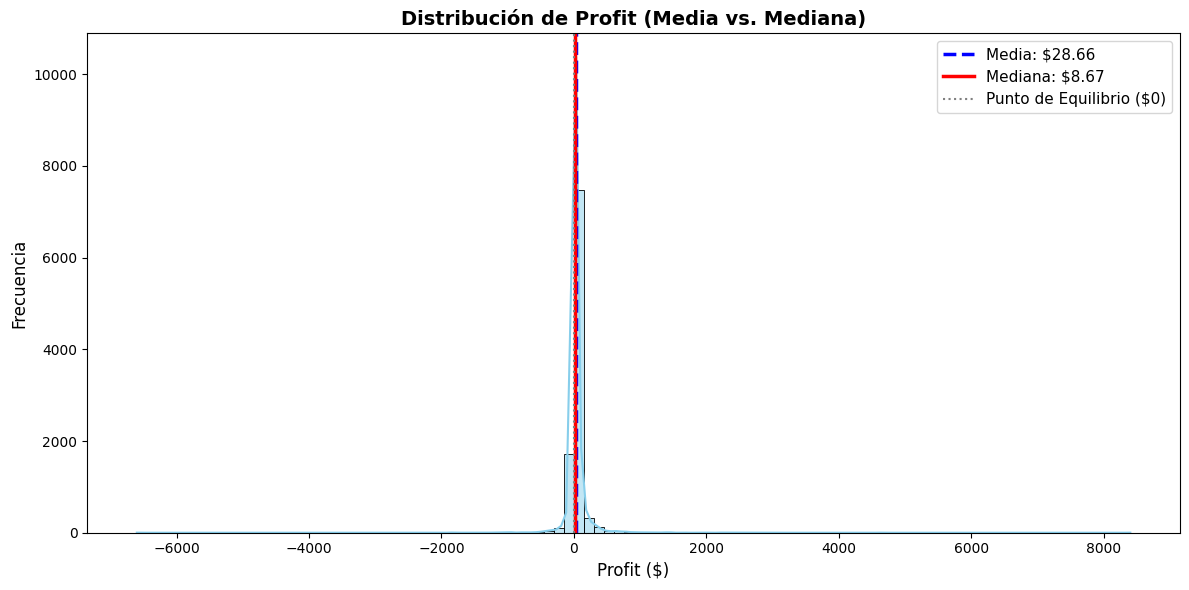

In [14]:
# Histograma

media_profit = df["Profit"].mean()
mediana_profit = df["Profit"].median()

plt.figure(figsize=(12, 6))

sns.histplot(data=df, x="Profit", bins=100, kde=True, color="skyblue", alpha=0.5)

# Líneas verticales con etiquetas
plt.axvline(
    media_profit,
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label=f"Media: ${media_profit:.2f}",
)
plt.axvline(
    mediana_profit,
    color="red",
    linestyle="-",
    linewidth=2.5,
    label=f"Mediana: ${mediana_profit:.2f}",
)
plt.axvline(
    0, color="gray", linestyle=":", linewidth=1.5, label="Punto de Equilibrio ($0)"
)

# DESCOMENTAR para hacer zoom en la zona central ignorando temporalmente
# outliers extremos para ver mejor el pico de la distribución
#plt.xlim(-500, 500)

plt.title(
    "Distribución de Profit (Media vs. Mediana)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Profit ($)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

En el histograma podemos observar muchas transacciones cercanas a 0 que nos indicarían que tienen un Profit con pérdidas y ganancias. Además se notan outliers extremos tanto negativa como positivamente.

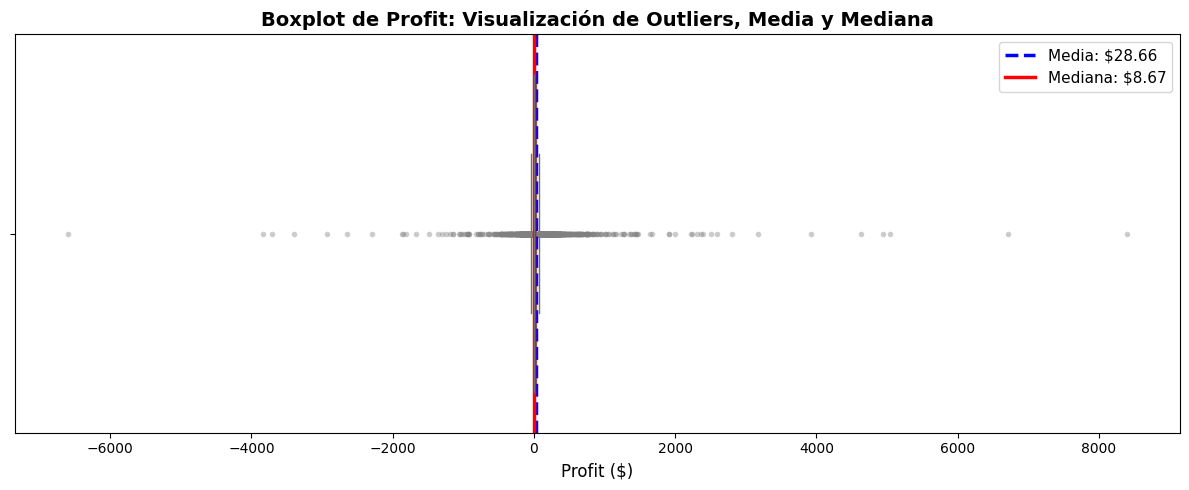

In [15]:
# Boxplot
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x="Profit",
    color="skyblue",
    fliersize=4,
    flierprops={
        "marker": "o",
        "markerfacecolor": "gray",
        "markeredgecolor": "none",
        "alpha": 0.4,
    },
)

# Líneas verticales con carteles/leyendas
plt.axvline(
    media_profit,
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label=f"Media: ${media_profit:.2f}",
)
plt.axvline(
    mediana_profit,
    color="red",
    linestyle="-",
    linewidth=2.5,
    label=f"Mediana: ${mediana_profit:.2f}",
)

# DESCOMENTAR para hacer zoom temporalmente
#plt.xlim(-500, 500)

plt.title(
    "Boxplot de Profit: Visualización de Outliers, Media y Mediana",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Profit ($)", fontsize=12)
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

Podemos notar que hay muchos outliers y que profit se centra en 0.

In [16]:
# Rango intercuartílico
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 1.72875
Q3: 29.364
IQR: 27.63525
Límite inferior: -39.724125
Límite superior: 70.816875


Conteo de Outliers

In [17]:
outliers = df[
    (df["Profit"] < limite_inferior) |
    (df["Profit"] > limite_superior)
]

print("Cantidad de outliers:", len(outliers))
print("Porcentaje de outliers:",
      round(len(outliers) / len(df) * 100, 2), "%")

Cantidad de outliers: 1881
Porcentaje de outliers: 18.82 %


Operaciones más extremas

In [18]:
print("10 mayores profits:")
display(df.nlargest(10, "Profit")[
    ["Order ID", "Product Name", "Sales", "Quantity", "Discount", "Profit"]
])

10 mayores profits:


,Order ID,Product Name,Sales,Quantity,Discount,Profit
6826,CA-2016-118689,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,CA-2017-140151,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
4190,CA-2017-166709,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,CA-2016-117121,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,CA-2014-116904,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
2623,CA-2017-127180,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
509,CA-2015-145352,Fellowes PB500 Electric Punch Plastic Comb Bin...,6354.950,5,0.0,3177.4750
8488,CA-2016-158841,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
7666,US-2016-140158,Hewlett Packard LaserJet 3310 Copier,5399.910,9,0.0,2591.9568
6520,CA-2017-138289,GBC DocuBind P400 Electric Binding System,5443.960,4,0.0,2504.2216


In [19]:
print("10 menores profits:")
display(df.nsmallest(10, "Profit")[
    ["Order ID", "Product Name", "Sales", "Quantity", "Discount", "Profit"]
])

10 menores profits:


,Order ID,Product Name,Sales,Quantity,Discount,Profit
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
683,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
9774,CA-2014-169019,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
3011,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800
4991,US-2017-122714,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845
3151,CA-2015-147830,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912
5310,CA-2017-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820
9639,CA-2015-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124
1199,CA-2016-130946,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464
2697,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784


##b) Relación entre características predictoras y Profit

Profit vs Sales

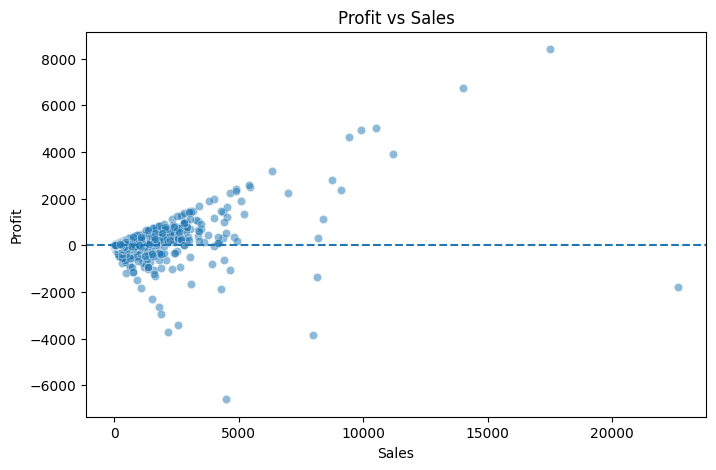

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Profit vs Sales")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

En el gráfico de dispersión entre Sales y Profit se observa que, para valores bajos de Sales, los valores de Profit se encuentran concentrados cerca de cero. A medida que Sales aumenta, los valores de Profit presentan una mayor dispersión, tanto en valores positivos como negativos, aunque se notan mas puntos positivos.

Esto indica que existe una relación entre ambas variables, pero que Sales por sí sola no determina el valor de Profit. Para niveles elevados de ventas pueden existir tanto transacciones con ganancias como transacciones con pérdidas.

También se obseravan valores atípicos.



Profit vs Quantity

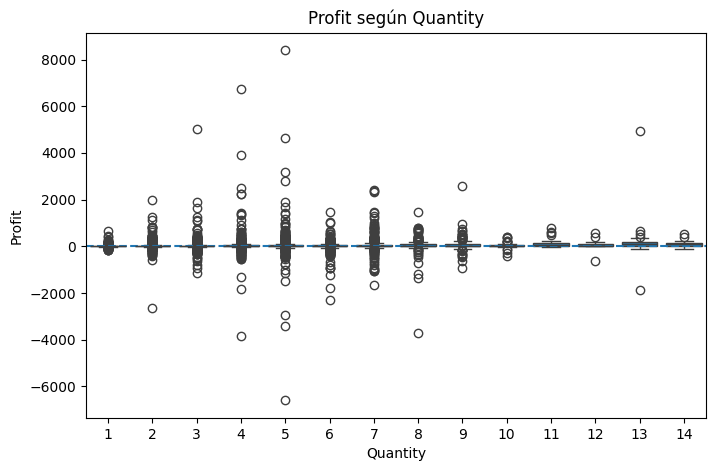

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Quantity",
    y="Profit"
)

plt.axhline(0, linestyle="--")

plt.title("Profit según Quantity")
plt.xlabel("Quantity")
plt.ylabel("Profit")

plt.show()

Para los distintos niveles de Quantity aparecen numerosos puntos alejados de los bigotes, lo que indica la presencia de valores atípicos. Estos valores representan transacciones cuyo beneficio o pérdida se encuentra alejado del comportamiento central de las observaciones.

Profit vs Discount

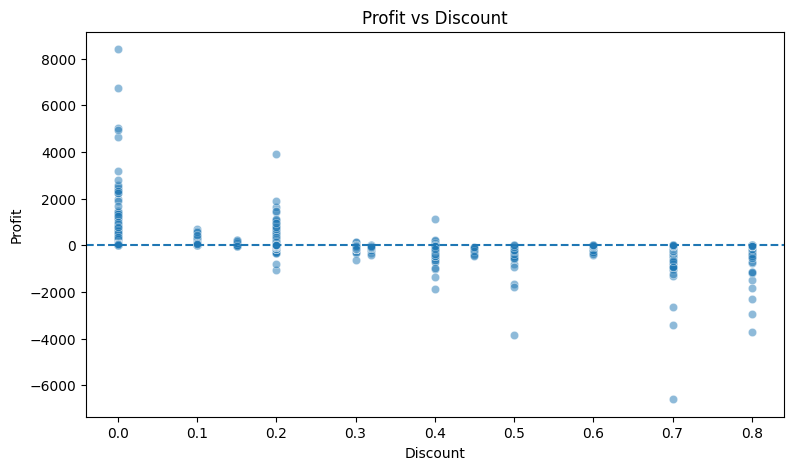

In [22]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

El gráfico de dispersión entre Profit y Discount muestra una relación negativa entre ambas variables. Cuando el descuento es igual a 0, los valores de Profit se concentran principalmente en valores positivos, indicando que las transacciones sin descuento tienden a generar beneficios.

A medida que aumenta el nivel de Discount, se observa una disminución del Profit. Esta tendencia se hace evidente a partir  de un descuento de 0.2, donde aparecen valores de Profit marcadamente negativos, lo que indica que los descuentos elevados están asociados con una mayor probabilidad de generar pérdidas.


Promedio de Profit para cada nivel de descuento

In [23]:
profit_discount = (
    df.groupby("Discount")["Profit"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

display(profit_discount)

,Discount,mean,median,count
0,0.00,66.900292,15.9952,4798
1,0.10,96.055074,54.3240,94
2,0.15,27.288298,14.0980,52
3,0.20,24.702572,6.4944,3657
4,0.30,-45.679636,-25.3764,227
5,0.32,-88.560656,-46.9764,27
6,0.40,-111.927429,-57.6242,206
7,0.45,-226.646464,-167.3184,11
8,0.50,-310.703456,-185.2767,66
9,0.60,-43.077212,-12.0617,138


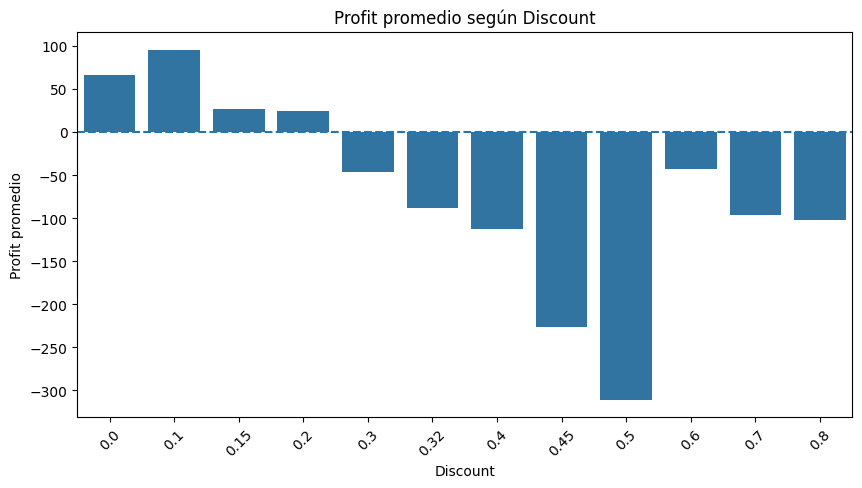

In [24]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=profit_discount,
    x="Discount",
    y="mean"
)

plt.axhline(0, linestyle="--")

plt.title("Profit promedio según Discount")
plt.xlabel("Discount")
plt.ylabel("Profit promedio")

plt.xticks(rotation=45)

plt.show()

Matriz de correlación

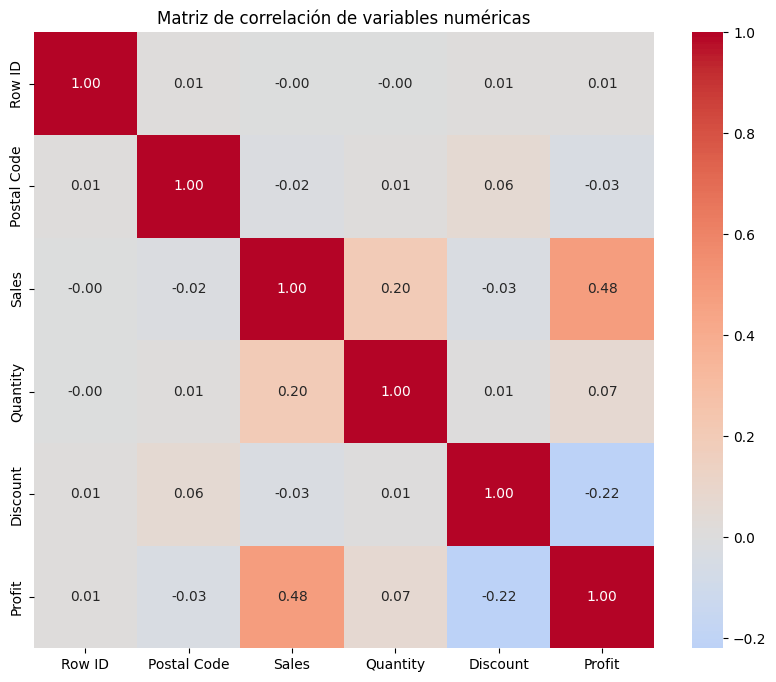

In [25]:
corr = df[cols_numericas].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de variables numéricas")

plt.show()

Se observa una correlación positiva moderada entre Sales y Profit (r = 0.48), lo que indica que, en general, mayores niveles de ventas tienden a asociarse con mayores niveles de beneficio.

Entre Discount y Profit se observa una correlación negativa débil (r = -0.22). Esto indica que mayores niveles de descuento tienden a asociarse con menores niveles de beneficio. Aunque la relación lineal no es fuerte, el signo negativo coincide con lo observado en el scatterplot, donde los valores elevados de descuento presentan una mayor presencia de beneficios bajos o negativos.

Quantity y Sales presentan una correlación positiva débil (0.20), indicando que vender una mayor cantidad de unidades tiende a asociarse con un incremento en las ventas, aunque la relación no es fuerte.

## c) Identificación de variables de alta cardinalidad

In [26]:
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

cardinality = pd.DataFrame({
    "Variable": categorical_cols,
    "Valores únicos": [
        df[col].nunique()
        for col in categorical_cols
    ]
})

cardinality = cardinality.sort_values(
    "Valores únicos",
    ascending=False
)

display(cardinality)

,Variable,Valores únicos
0,Order ID,5009
9,Product ID,1862
12,Product Name,1850
2,Customer ID,793
3,Customer Name,793
6,City,531
7,State,49
11,Sub-Category,17
1,Ship Mode,4
8,Region,4


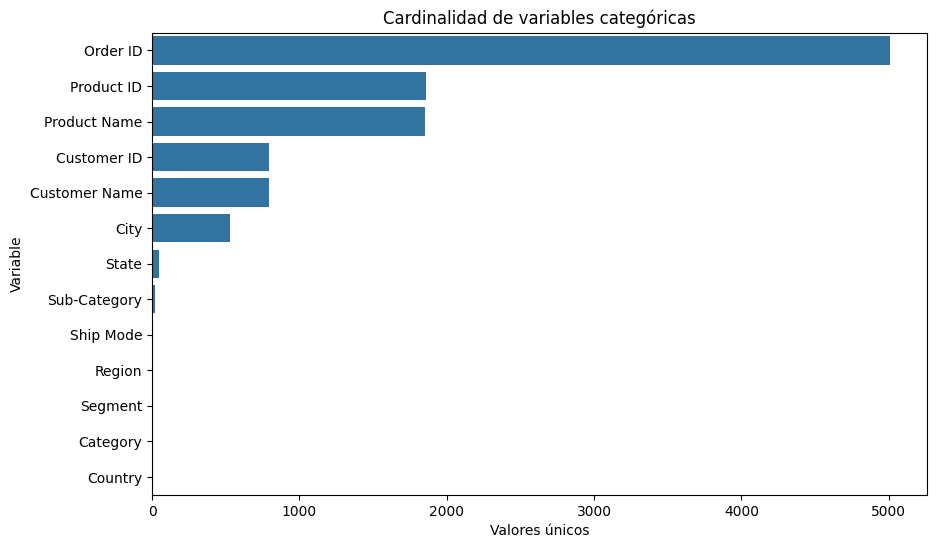

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cardinality,
    x="Valores únicos",
    y="Variable"
)

plt.title("Cardinalidad de variables categóricas")

plt.show()

In [28]:
high_cardinality = [
    "Customer ID",
    "Customer Name",
    "City",
    "State",
    "Product ID",
    "Product Name",
    "Order ID"
]

for col in high_cardinality:
    if col in df.columns:
        print(
            f"{col}: {df[col].nunique()} valores únicos"
        )

Customer ID: 793 valores únicos
Customer Name: 793 valores únicos
City: 531 valores únicos
State: 49 valores únicos
Product ID: 1862 valores únicos
Product Name: 1850 valores únicos
Order ID: 5009 valores únicos


Tratamiento de variables de alta cardinalidad.

Se analizaron las variables categóricas mediante su cantidad de valores únicos. Se identificaron variables con cardinalidad elevada, principalmente Order ID (5009), Product ID (1862), Product Name (1850), Customer ID (793), Customer Name (793) y City (531).
Las variables Order ID, Product ID, Product Name, Customer ID y Customer Name deberán ser descartadas debido a que funcionan principalmente como identificadores y su codificación mediante One-Hot Encoding generaría una dimensionalidad elevada sin aportar una representación generalizable adecuada para el modelo inicial.

La variable City, a pesar de contener información geográfica potencialmente relevante, también debería ser excluida inicialmente debido a su elevada cardinalidad (531 categorías).

Por otro lado, State (49 categorías), Sub-Category (17), Ship Mode (4), Region (4), Segment (3) y Category (3) deberían ser conservadas y serán transformadas mediante One-Hot Encoding, dado que presentan una cardinalidad manejable y pueden aportar información relevante para la predicción de Profit.

Finalmente, Country presenta un único valor, por lo que deberá ser eliminada al no aportar variabilidad al modelo.

Conclusión del EDA

 La variable objetivo Profit presenta valores tanto positivos como negativos, representando respectivamente ganancias y pérdidas en las transacciones. La distribución presenta asimetría y valores extremos, por lo que se identificaron outliers mediante el criterio del rango intercuartílico. Estos valores no fueron eliminados automáticamente debido a que pueden representar transacciones comerciales reales.

Entre las variables numéricas, Sales, Quantity y especialmente Discount presentan relaciones relevantes con Profit. El análisis gráfico permite observar que el nivel de descuento tiene una influencia importante sobre la rentabilidad y que determinados descuentos pueden estar asociados con valores negativos de Profit.

Respecto de las variables categóricas, Ship Mode, Segment, Region, Category y Sub-Category presentan una cardinalidad manejable y pueden ser transformadas mediante One-Hot Encoding. En cambio, variables como Customer ID, Customer Name, Product ID, Product Name y Order ID presentan alta cardinalidad o funcionan principalmente como identificadores, por lo que se propone excluirlas inicialmente para evitar una dimensionalidad excesiva y reducir el riesgo de sobreajuste.


# Punto 2 - PREPROCESAMIENTO

## a) Eliminar columnas no predictivas

In [29]:
columns_to_drop = [
    "Row ID",
    "Order ID",
    "Customer ID",
    "Customer Name",
    "City",
    "Country",
    "Product ID",
    "Product Name",
    "Postal Code"
]

df_model = df.drop(columns=columns_to_drop)

In [30]:
print("Columnas eliminadas:")
print(columns_to_drop)

print("\nDimensiones:")
print(df_model.shape)



Columnas eliminadas:
['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'City', 'Country', 'Product ID', 'Product Name', 'Postal Code']

Dimensiones:
(9994, 12)


In [31]:
df_model.head()

,Order Date,Ship Date,Ship Mode,Segment,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,2016-11-11,Second Class,Consumer,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2016-11-08,2016-11-11,Second Class,Consumer,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,2016-06-12,2016-06-16,Second Class,Corporate,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,2015-10-11,2015-10-18,Standard Class,Consumer,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,2015-10-11,2015-10-18,Standard Class,Consumer,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## b) Extraer características de las fechas

De Order Date
- Año
- Mes
- Día
- Trimestre
- Día de la semana

In [32]:
df_model["Order_Year"] = df_model["Order Date"].dt.year
df_model["Order_Month"] = df_model["Order Date"].dt.month
df_model["Order_Day"] = df_model["Order Date"].dt.day
df_model["Order_Quarter"] = df_model["Order Date"].dt.quarter
df_model["Order_DayOfWeek"] = df_model["Order Date"].dt.dayofweek
df_model["Order_Quarter"] = df_model["Order Date"].dt.quarter


De Ship Date

- La característica más útil es la demora de envío.

In [33]:
df_model["Ship_Days"] = (
    df_model["Ship Date"] - df_model["Order Date"]
).dt.days

Eliminamos las variables

In [34]:
df_model = df_model.drop(columns=["Order Date", "Ship Date"], errors="ignore")

## c) Codificación de variables categóricas

In [35]:
# Variables de baja/media cardinalidad para One-Hot Enc
low_cardinality = ["Ship Mode", "Segment", "Region", "State", "Category", "Sub-Category"]

df_model = pd.get_dummies(
    df_model, columns=low_cardinality, drop_first=True, dtype=int
)

print(f"Dimensiones finales del dataset tras el filtrado: {df_model.shape}")

Dimensiones finales del dataset tras el filtrado: (9994, 84)


## c) Escalar variables

Separación de características y Profit

In [36]:
# Separar características predictoras (X) y variable objetivo (y)
X = df_model.drop(columns=["Profit"])
y = df_model["Profit"]

Separación Train-Test

In [37]:
# Split Train/Test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Escalado

In [38]:
cols_numericas_esc = ["Sales", "Quantity", "Discount", "Ship_Days"]

scaler = RobustScaler()

X_train[cols_numericas_esc] = scaler.fit_transform(X_train[cols_numericas_esc])
X_test[cols_numericas_esc] = scaler.transform(X_test[cols_numericas_esc])

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (7995, 83) | X_test shape: (1999, 83)


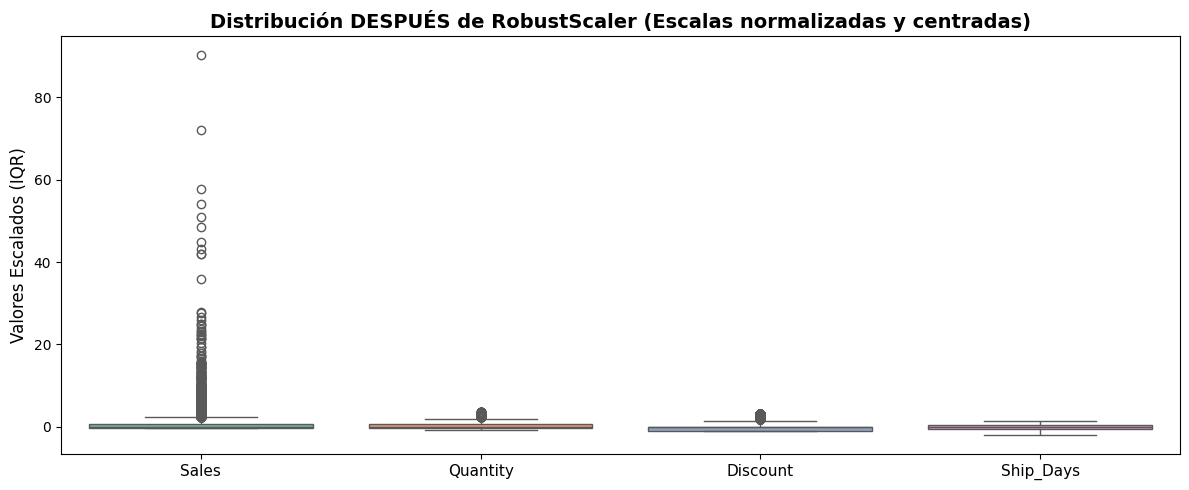

In [39]:
# Gráfico
plt.figure(figsize=(12, 5))
sns.boxplot(data=X_train[cols_numericas_esc], palette="Set2")
plt.title(
    "Distribución DESPUÉS de RobustScaler (Escalas normalizadas y centradas)",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Valores Escalados (IQR)", fontsize=12)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

Elegimos Robust Scaler porque usa la Mediana y el Rango Intercuartílico (IQR): En lugar de la media y la desviación. RobustScaler centra los datos usando la mediana (el valor del medio) y escala los datos usando el rango entre el 25% y el 75% de los datos (IQR).

Es inmune a los extremos debido a que la mediana y el IQR no se ven afectados por ningún número de un outlier.


Conclusión preprocesamiento

Se eliminaron las variables identificadoras Row ID, Order ID, Customer ID, Customer Name, Product ID y Product Name, debido a su carácter identificativo y/o elevada cardinalidad. También se eliminaron Country, por presentar un único valor, y City, debido a su elevada cardinalidad (531 categorías). Postal Code también fue descartado debido a que, a pesar de estar almacenado como variable numérica, representa un código geográfico y no una magnitud continua.

Las variables Order Date y Ship Date fueron transformadas inicialmente al tipo datetime. A partir de Order Date se extrajeron año, mes, día, trimestre y día de la semana. Además, se creó Ship_Days, correspondiente a la cantidad de días transcurridos entre el pedido y el envío. Finalmente, las fechas originales fueron eliminadas.

Para las variables categóricas Ship Mode, Segment, Region, State, Category y Sub-Category se utilizó One-Hot Encoding. Esta técnica resulta adecuada porque las variables presentan una cardinalidad baja o moderada y no poseen un orden intrínseco. Las variables de muy alta cardinalidad fueron descartadas inicialmente para evitar una expansión excesiva de la dimensionalidad.

Las variables numéricas fueron estandarizadas mediante RobustScaler utiliza la mediana y el rango intercuartílico (IQR), proporcionando una transformación más robusta frente a outliers. El escalador fue ajustado exclusivamente sobre el conjunto de entrenamiento después de realizar la división train/test, evitando de esta manera data leakage.

# PUNTO 3 - DISEÑO E IMPLEMENTACIÓN DE LA RED NEURONAL

In [47]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7995, 83)
X_test: (1999, 83)
y_train: (7995,)
y_test: (1999,)



- Tenemos 7995 observaciones para entrenar
- 1999 observaciones para evaluar
- la red recibe 83 variables de entrada


## a) Función de activación en la capa de salida.

In [57]:
output_layer = layers.Dense(1, activation="linear")

print("Capa de salida:")
print(output_layer)

Capa de salida:
<Dense name=dense_16, built=False>


Para la capa de salida se utilizará una función de activación lineal (linear), ya que el problema corresponde a una tarea de regresión y la variable objetivo Profit es continua y puede tomar valores tanto positivos como negativos.

La función lineal no restringe el rango de la predicción, permitiendo que la red genere valores negativos, cero o positivos. Esto resulta adecuado para representar tanto pérdidas como ganancias.

Una función ReLU no sería adecuada para la salida porque únicamente permite obtener valores mayores o iguales a cero, mientras que en nuestro conjunto de datos existen transacciones con pérdidas. Por otro lado, una función Sigmoid limita la salida al intervalo entre 0 y 1, lo que tampoco resulta apropiado para representar los valores de Profit.

## b) Función de costo. Comparar MSE, MAE y Huber Loss en el contexto de la distribución de Profit.

Visualizamos los errores

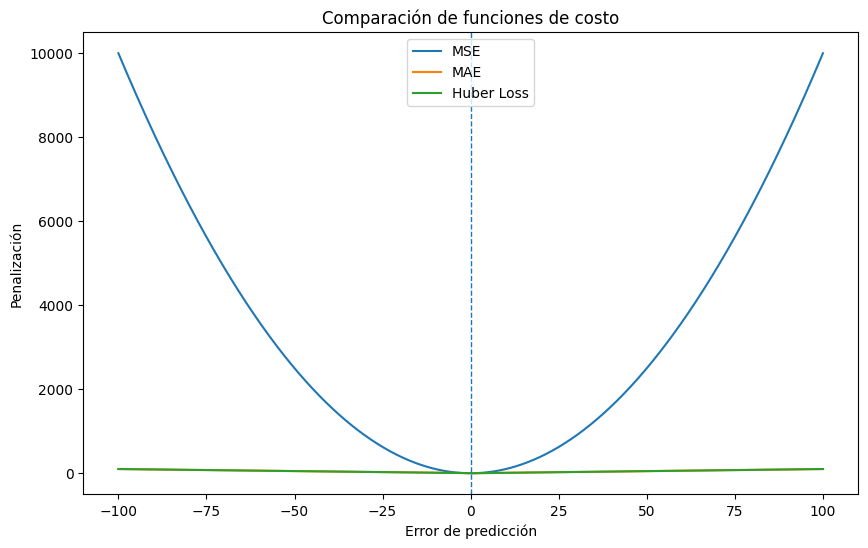

In [54]:

errores = np.linspace(-100, 100, 1000)

# MSE
mse = errores ** 2

# MAE
mae = np.abs(errores)

# Huber
delta = 1.0

huber = np.where(
    np.abs(errores) <= delta,
    0.5 * errores**2,
    delta * (np.abs(errores) - 0.5 * delta)
)

plt.figure(figsize=(10, 6))

plt.plot(errores, mse, label="MSE")
plt.plot(errores, mae, label="MAE")
plt.plot(errores, huber, label="Huber Loss")

plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Error de predicción")
plt.ylabel("Penalización")
plt.title("Comparación de funciones de costo")

plt.legend()
plt.show()

Función de costo

In [58]:
# MSE
loss_mse = keras.losses.MeanSquaredError()

# MAE
loss_mae = keras.losses.MeanAbsoluteError()

# Huber
loss_huber = keras.losses.Huber()

print("Funciones de costo:")
print("MSE   :", loss_mse)
print("MAE   :", loss_mae)
print("Huber :", loss_huber)

Funciones de costo:
MSE   : <LossFunctionWrapper(<function mean_squared_error at 0x795ba7a4ee80>, kwargs={})>
MAE   : <LossFunctionWrapper(<function mean_absolute_error at 0x795ba7a4ef20>, kwargs={})>
Huber : <LossFunctionWrapper(<function huber at 0x795ba7a4f1a0>, kwargs={'delta': 1.0})>


 MSE: Penaliza fuertemente los errores grandes. Es sensible a los valores extremos de Profit.

MAE: Utiliza el valor absoluto del error. Es más robusto frente a valores extremos.

Huber: Combina características de MSE y MAE. Para errores pequeños se comporta como MSE y para errores grandes es más robusto.

In [59]:
def crear_modelo(loss_function):

    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.20),

        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_function,
        metrics=[
            keras.metrics.MeanAbsoluteError(name="MAE"),
            keras.metrics.MeanSquaredError(name="MSE")
        ]
    )

    return model

Entrenamos los modelos

In [60]:
# Modelo utilizando MSE
model_mse = crear_modelo(loss_mse)

# Modelo utilizando MAE
model_mae = crear_modelo(loss_mae)

# Modelo utilizando Huber
model_huber = crear_modelo(loss_huber)

In [61]:
history_mse = model_mse.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    ],
    verbose=1
)

history_mae = model_mae.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    ],
    verbose=1
)

history_huber = model_huber.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - MAE: 103.7781 - MSE: 71336.8594 - loss: 71336.8594 - val_MAE: 66.8208 - val_MSE: 34045.4023 - val_loss: 34045.4023
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - MAE: 73.2256 - MSE: 62818.0195 - loss: 62818.0195 - val_MAE: 54.5786 - val_MSE: 33657.3164 - val_loss: 33657.3164
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - MAE: 68.7540 - MSE: 62759.2891 - loss: 62759.2891 - val_MAE: 55.4187 - val_MSE: 33633.6250 - val_loss: 33633.6250
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - MAE: 68.4803 - MSE: 62552.6836 - loss: 62552.6836 - val_MAE: 53.1642 - val_MSE: 33693.0430 - val_loss: 33693.0430
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 65.9394 - MSE: 62517.3516 - loss: 62517.3516 - val_MAE: 56.4219 - val_MSE: 33621.6992 - val_loss: 33621.6992
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 65.5231 - MSE: 62166.8789 - loss: 62166.8789 - val_MAE: 61.1288 - val_MSE: 33744.3164 - val_lo

Predicciones

In [62]:
pred_mse = model_mse.predict(X_test).ravel()
pred_mae = model_mae.predict(X_test).ravel()
pred_huber = model_huber.predict(X_test).ravel()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Tabla comparativa

In [64]:
resultados = pd.DataFrame({
    "Modelo": ["MSE", "MAE", "Huber"],
    "MAE": [
        mean_absolute_error(y_test, pred_mse),
        mean_absolute_error(y_test, pred_mae),
        mean_absolute_error(y_test, pred_huber)
    ],
    "MSE": [
        mean_squared_error(y_test, pred_mse),
        mean_squared_error(y_test, pred_mae),
        mean_squared_error(y_test, pred_huber)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_mse)),
        np.sqrt(mean_squared_error(y_test, pred_mae)),
        np.sqrt(mean_squared_error(y_test, pred_huber))
    ],
    "R2": [
        r2_score(y_test, pred_mse),
        r2_score(y_test, pred_mae),
        r2_score(y_test, pred_huber)
    ]
})

print(resultados.round(3))

  Modelo     MAE         MSE     RMSE     R2
0    MSE  56.481  133039.465  364.746 -1.744
1    MAE  41.042  102305.472  319.852 -1.110
2  Huber  41.057  106724.903  326.688 -1.201


Los tres modelos presentan un desempeño limitado en el conjunto de prueba, ya que los valores de R² son negativos, ésto indica que la red neuronal actual está teniendo dificultades para capturar patrones predictivos complejos solo con las columnas actuales, o requiere ajustes en hiperparámetros (más épocas con Early Stopping, ajuste de la tasa de aprendizaje, o incluir/revisar la codificación de variables).  

Sin embargo, el modelo entrenado con MAE obtuvo el mejor desempeño relativo entre las tres funciones de pérdida, presentando los menores valores de MAE, MSE y RMSE y el R² menos negativo.

## c) Número de capas ocultas, neuronas y funciones de activación

In [65]:


model_mse.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 64)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,469 (87.77 KB)

 Trainable params: 7,489 (29.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,980 (58.52 KB)

Número de capas ocultas, neuronas:
- 2 capas ocultas.
- Primera capa: 64 neuronas, activación ReLU.
- Segunda capa: 32 neuronas, activación ReLU.
- Dropout de 20% después de cada capa oculta para reducir el riesgo de sobreajuste.
- Capa de salida: 1 neurona, activación lineal, porque Profit es una variable numérica continua que puede ser negativa o positiva.

Función de activación está definido en la Función "Crear modelo"

## d) Optimizador, tasa de aprendizaje y estrategia de regularización.


In [66]:
model_final = keras.Sequential([

    layers.Input(shape=(X_train.shape[1],)),

    # Primera capa oculta
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),

    # Segunda capa oculta
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),

    # Salida
    layers.Dense(1, activation="linear")
])

# Optimizador Adam con learning rate = 0.001
model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    loss=keras.losses.Huber(),

    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        keras.metrics.MeanSquaredError(name="MSE")
    ]
)

model_final.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 64)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,489 (29.25 KB)

 Trainable params: 7,489 (29.25 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.Huber(),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        keras.metrics.MeanSquaredError(name="MSE")
    ]
)

In [70]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [71]:
history = model_final.fit(
    X_train,
    y_train,

    validation_split=0.20,

    epochs=200,

    batch_size=32,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - MAE: 31.4417 - MSE: 22236.0703 - loss: 30.9571 - val_MAE: 27.5463 - val_MSE: 7592.4341 - val_loss: 27.0663
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 30.8507 - MSE: 20935.4961 - loss: 30.3685 - val_MAE: 26.3759 - val_MSE: 7754.3589 - val_loss: 25.8918
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 32.4727 - MSE: 20407.4805 - loss: 31.9888 - val_MAE: 27.8157 - val_MSE: 8412.7656 - val_loss: 27.3335
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 32.0847 - MSE: 20278.7148 - loss: 31.6014 - val_MAE: 27.4508 - val_MSE: 7216.4170 - val_loss: 26.9639
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - MAE: 30.8140 - MSE: 22794.1719 - loss: 30.3302 - val_MAE: 26.6429 - val_MSE: 6720.4766 - val_loss: 26.1597
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 31.8671 - MSE: 24982.1562 - loss: 31.3845 - val_MAE: 28.0451 - val_MSE: 6662.8438 - val_loss: 27.5646
Epoch 7/200
200/200 ━━━━━━━━

Comparamos modelos

In [72]:
# Entrenar MSE
history_mse = model_mse.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Entrenar MAE
history_mae = model_mae.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Entrenar Huber
history_huber = model_huber.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 52.2823 - MSE: 28683.7949 - loss: 28683.7949 - val_MAE: 42.4137 - val_MSE: 10591.0020 - val_loss: 10591.0020
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 50.3678 - MSE: 26732.8477 - loss: 26732.8477 - val_MAE: 42.4761 - val_MSE: 11380.0830 - val_loss: 11380.0830
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 51.4523 - MSE: 27673.3008 - loss: 27673.3008 - val_MAE: 50.6307 - val_MSE: 12558.7178 - val_loss: 12558.7178
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 45.7241 - MSE: 24787.3887 - loss: 24787.3887 - val_MAE: 39.1312 - val_MSE: 10677.6660 - val_loss: 10677.6660
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 45.6976 - MSE: 24057.2559 - loss: 24057.2559 - val_MAE: 38.8601 - val_MSE: 10849.7471 - val_loss: 10849.7471
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 47.6132 - MSE: 26052.4902 - loss: 26052.4902 - val_MAE: 40.0159 - val_MSE: 10720.4551 - val_los

Evaluamos los modelos

In [73]:
# Predicciones
pred_mse = model_mse.predict(X_test).ravel()
pred_mae = model_mae.predict(X_test).ravel()
pred_huber = model_huber.predict(X_test).ravel()

# Resultados
resultados = pd.DataFrame({

    "Modelo": ["MSE", "MAE", "Huber"],

    "MAE": [
        mean_absolute_error(y_test, pred_mse),
        mean_absolute_error(y_test, pred_mae),
        mean_absolute_error(y_test, pred_huber)
    ],

    "MSE": [
        mean_squared_error(y_test, pred_mse),
        mean_squared_error(y_test, pred_mae),
        mean_squared_error(y_test, pred_huber)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_mse)),
        np.sqrt(mean_squared_error(y_test, pred_mae)),
        np.sqrt(mean_squared_error(y_test, pred_huber))
    ],

    "R2": [
        r2_score(y_test, pred_mse),
        r2_score(y_test, pred_mae),
        r2_score(y_test, pred_huber)
    ]
})

resultados

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Modelo,MAE,MSE,RMSE,R2
0,MSE,57.717532,120680.413769,347.390866,-1.489019
1,MAE,45.122237,109888.363994,331.494139,-1.266435
2,Huber,41.198245,107267.943379,327.517852,-1.212389


Entre las funciones de pérdida que evaluamos, Huber presentó el mejor desempeño relativo, pero los valores negativos de R² indican que el modelo todavía presenta una capacidad predictiva limitada sobre el conjunto de prueba.

La estrategia de regularización que usamos es:
Dropout del 20% después de cada capa oculta, complementado con EarlyStopping con una paciencia de 20 épocas y restauración de los mejores pesos.

Se utilizó Dropout para reducir la dependencia excesiva de determinadas neuronas y disminuir el riesgo de sobreajuste. Además, EarlyStopping permite detener el entrenamiento cuando el desempeño sobre el conjunto de validación deja de mejorar, evitando entrenamientos innecesarios y una posible pérdida de capacidad de generalización.

# PUNTO 4 - ENTRENAMIENTO Y CURVAS DE APRENDIZAJE

Entrenamiento y curvas de aprendizaje

In [74]:
# Semilla para reproducibilidad
tf.random.set_seed(42)

# Modelo final
model_final = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.20),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.20),
    keras.layers.Dense(1, activation="linear")
])

model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.Huber(),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        keras.metrics.MeanSquaredError(name="MSE")
    ]
)

# Early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# Entrenamiento
history = model_final.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - MAE: 74.1742 - MSE: 64702.5742 - loss: 73.6778 - val_MAE: 52.2080 - val_MSE: 34078.7734 - val_loss: 51.7197
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 59.1061 - MSE: 62728.2109 - loss: 58.6142 - val_MAE: 51.9476 - val_MSE: 34015.6953 - val_loss: 51.4578
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.5388 - MSE: 62719.9648 - loss: 58.0484 - val_MAE: 51.8514 - val_MSE: 33972.3945 - val_loss: 51.3592
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.2850 - MSE: 62743.5000 - loss: 57.7938 - val_MAE: 51.8166 - val_MSE: 33936.6992 - val_loss: 51.3245
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.2050 - MSE: 62691.5859 - loss: 57.7146 - val_MAE: 51.8176 - val_MSE: 33941.6602 - val_loss: 51.3250
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.1374 - MSE: 62725.1484 - loss: 57.6465 - val_MAE: 51.8120 - val_MSE: 33933.9609 - val_loss: 51.3199
Epoch 7/200
200/200 ━━

Graficar las curvas

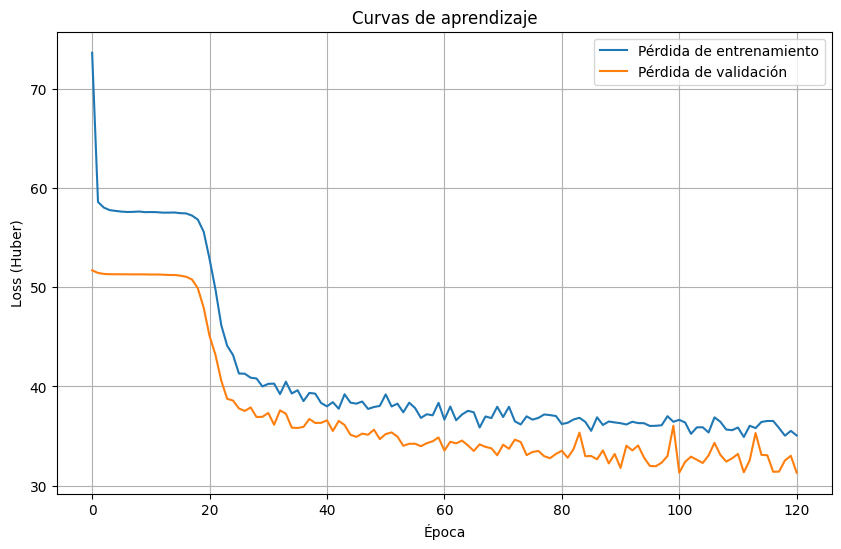

In [75]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Pérdida de entrenamiento")
plt.plot(history.history["val_loss"], label="Pérdida de validación")

plt.xlabel("Época")
plt.ylabel("Loss (Huber)")
plt.title("Curvas de aprendizaje")
plt.legend()
plt.grid(True)

plt.show()

La curva de pérdida de entrenamiento disminuye aproximadamente de 75 a 35, mientras que la pérdida de validación disminuye de aproximadamente 52 a 31. La tendencia descendente de ambas curvas indica que el modelo aprende progresivamente durante el entrenamiento y logra mejorar su desempeño también sobre datos de validación.

La pérdida de validación se mantiene por debajo de la pérdida de entrenamiento. Este comportamiento no indica necesariamente un problema, ya que durante el entrenamiento se aplica Dropout del 20%, mientras que durante la validación esta regularización se desactiva. Por otro lado, se observan algunos picos puntuales en la pérdida de validación alrededor de las épocas 85, 95 y 115 pero no existe un incremento sostenido de dicha pérdida.

Por lo tanto, no se observa evidencia clara de overfitting ni de underfitting en las curvas de aprendizaje. El modelo presenta un comportamiento de aprendizaje adecuado, aunque las fluctuaciones de la validación justifican mantener mecanismos de regularización como Dropout y EarlyStopping.

Modelo corregido

In [77]:
model_corregido = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.30),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.30),
    keras.layers.Dense(1, activation="linear")
])

model_corregido.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.Huber(),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        keras.metrics.MeanSquaredError(name="MSE")
    ]
)

early_stopping_corregido = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_corregido = model_corregido.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping_corregido],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - MAE: 108.7540 - MSE: 74189.9766 - loss: 108.2563 - val_MAE: 52.7451 - val_MSE: 34148.8906 - val_loss: 52.2594
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 60.5373 - MSE: 62937.7461 - loss: 60.0446 - val_MAE: 51.8723 - val_MSE: 33982.1172 - val_loss: 51.3811
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.8503 - MSE: 62852.9492 - loss: 58.3587 - val_MAE: 51.8692 - val_MSE: 33981.4023 - val_loss: 51.3780
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.6331 - MSE: 62771.0938 - loss: 58.1414 - val_MAE: 51.8189 - val_MSE: 33935.6836 - val_loss: 51.3268
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.3836 - MSE: 62732.1914 - loss: 57.8921 - val_MAE: 51.8268 - val_MSE: 33952.5391 - val_loss: 51.3339
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.3617 - MSE: 62697.3320 - loss: 57.8719 - val_MAE: 51.8329 - val_MSE: 33959.5586 - val_loss: 51.3402
Epoch 7/200
200/200 

Como corrección frente al posible sobreajuste se implementaron técnicas de regularización mediante Dropout del 20% después de cada capa oculta y EarlyStopping con una paciencia de 20 épocas, restaurando los mejores pesos obtenidos durante el entrenamiento. Al analizar las curvas de aprendizaje, no se observa un overfitting evidente, ya que la pérdida de validación no presenta un aumento sostenido mientras la pérdida de entrenamiento continúa disminuyendo. Por este motivo, no fue necesario incrementar el nivel de regularización ni modificar la arquitectura de la red.

Curva del modelo corregido

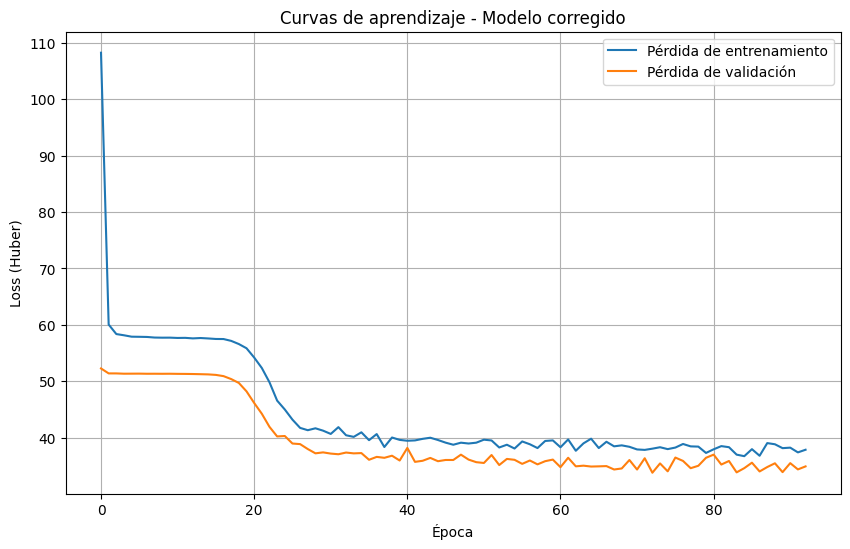

In [78]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_corregido.history["loss"],
    label="Pérdida de entrenamiento"
)

plt.plot(
    history_corregido.history["val_loss"],
    label="Pérdida de validación"
)

plt.xlabel("Época")
plt.ylabel("Loss (Huber)")
plt.title("Curvas de aprendizaje - Modelo corregido")
plt.legend()
plt.grid(True)

plt.show()

Comparamos los modelos

In [79]:
# Predicciones
y_pred_original = model_final.predict(X_test).ravel()
y_pred_corregido = model_corregido.predict(X_test).ravel()

# Métricas modelo original
mae_original = mean_absolute_error(y_test, y_pred_original)
mse_original = mean_squared_error(y_test, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original = r2_score(y_test, y_pred_original)

# Métricas modelo corregido
mae_corregido = mean_absolute_error(y_test, y_pred_corregido)
mse_corregido = mean_squared_error(y_test, y_pred_corregido)
rmse_corregido = np.sqrt(mse_corregido)
r2_corregido = r2_score(y_test, y_pred_corregido)

comparacion = pd.DataFrame({
    "Modelo": ["Original", "Corregido"],
    "MAE": [mae_original, mae_corregido],
    "MSE": [mse_original, mse_corregido],
    "RMSE": [rmse_original, rmse_corregido],
    "R2": [r2_original, r2_corregido]
})

comparacion

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Modelo,MAE,MSE,RMSE,R2
0,Original,48.435349,130833.704840,361.709420,-1.698430
1,Corregido,52.345678,150328.987036,387.722822,-2.100518


Como estrategia de corrección se evaluó aumentar la regularización mediante Dropout, pasando del 20% utilizado inicialmente al 30% en ambas capas ocultas. Sin embargo, la comparación sobre el conjunto de prueba mostró que esta modificación no mejoró el desempeño del modelo. El modelo original obtuvo un MAE de 48,44, un RMSE de 361,71 y un R² de -1,70, mientras que el modelo corregido obtuvo un MAE de 52,35, un RMSE de 387,72 y un R² de -2,10.

Dado que el modelo corregido presentó peores resultados en todas las métricas, se decidió conservar la arquitectura original con Dropout del 20%. Este resultado es consistente con las curvas de aprendizaje, donde no se había observado un overfitting evidente. Por lo tanto, aumentar la regularización no resultó beneficioso para este problema.

# PUNTO 5 - EVALUACIÓN DEL MODELO

Predicciones sobre test

In [80]:
y_pred = model_final.predict(X_test).ravel()

# Métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE:  48.44
MSE:  130833.70
RMSE: 361.71
R²:   -1.70


Sobre el conjunto de test, el modelo obtuvo un MAE de aproximadamente USD 48,44 y un RMSE de aproximadamente USD 361,71. El MAE indica que, en promedio, la predicción del beneficio "Profit" presenta un error absoluto de aproximadamente USD 48 por transacción. Esto significa que, para una venta individual, el beneficio estimado por el modelo puede diferir del beneficio real en aproximadamente USD 48 en promedio.

El RMSE, considerablemente superior al MAE, indica la presencia de algunas predicciones con errores muy elevados. Este comportamiento es consistente con la distribución de "Profit" observada durante el análisis exploratorio, donde se identificaron valores extremos y una importante dispersión.

Por otro lado, el modelo obtuvo un R² de aproximadamente -1,70. Un R² negativo indica que el modelo presenta un desempeño inferior al de una predicción basada simplemente en el promedio del beneficio del conjunto de entrenamiento. Por lo tanto, aunque la función de pérdida Huber presentó el mejor desempeño relativo entre las alternativas evaluadas, el modelo final presenta una capacidad predictiva limitada sobre el conjunto de test.

Las predicciones no deberían utilizarse de forma aislada para tomar decisiones críticas sobre rentabilidad. El modelo puede servir como una primera aproximación para estimar el beneficio, pero sería necesario mejorar su capacidad predictiva antes de utilizarlo como herramienta de apoyo para decisiones comerciales.

# PUNTO 6 - ANÁLISIS DE RESIDUOS

Cálculo de los residuos

In [81]:
# Predicciones del modelo final
y_pred = model_final.predict(X_test).ravel()

# Residuos
residuos = y_test.to_numpy() - y_pred

print(f"Cantidad de residuos: {len(residuos)}")
print(f"Error medio: {residuos.mean():.2f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cantidad de residuos: 1999
Error medio: -26.36


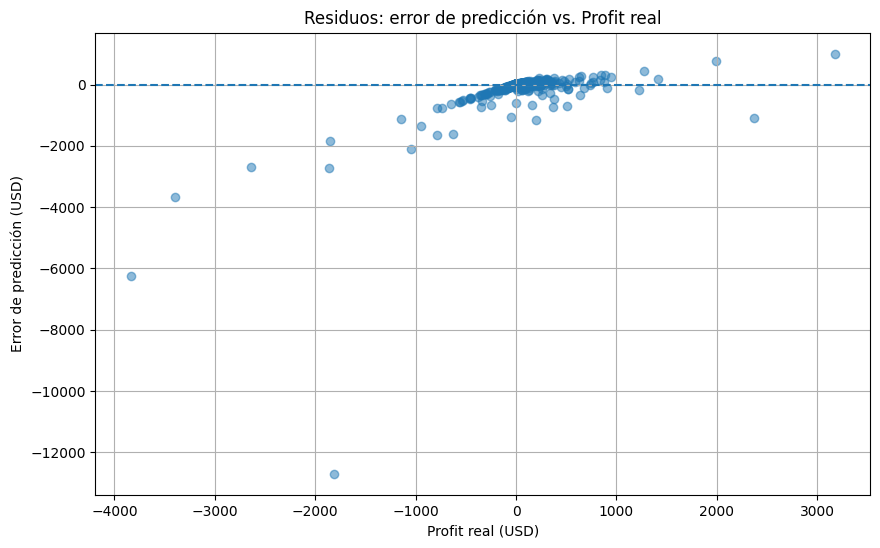

In [82]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, residuos, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Profit real (USD)")
plt.ylabel("Error de predicción (USD)")
plt.title("Residuos: error de predicción vs. Profit real")

plt.grid(True)
plt.show()

El gráfico de residuos muestra una concentración importante de observaciones en valores de "Profit" real comprendidos aproximadamente entre USD 0 y USD 1000. Los residuos se encuentran distribuidos alrededor de cero, aunque se observa una mayor cantidad de puntos por debajo de cero que por encima, lo que sugiere cierta tendencia del modelo a sobreestimar el beneficio en algunas observaciones.

También se identifican varios valores atípicos con errores de predicción considerablemente mayores que el resto. Esto indica que el error del modelo no es completamente constante y que existen determinadas transacciones para las cuales la predicción resulta considerablemente menos precisa. Este comportamiento es consistente con la elevada diferencia observada anteriormente entre el MAE y el RMSE, indicando la presencia de algunos errores extremos.

In [86]:
# Predicciones
y_pred = model_final.predict(X_test).ravel()

# Crear tabla
residuos_df = pd.DataFrame({
    "Profit_real": y_test.to_numpy(),
    "Profit_predicho": y_pred
}, index=y_test.index)

# Residuo = real - predicho
residuos_df["Residuo"] = (
    residuos_df["Profit_real"] -
    residuos_df["Profit_predicho"]
)

# Error absoluto
residuos_df["Error_absoluto"] = (
    residuos_df["Residuo"].abs()
)

# Top 5
top_5_errores = residuos_df.sort_values(
    "Error_absoluto",
    ascending=False
).head(5)

top_5_errores

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Profit_real,Profit_predicho,Residuo,Error_absoluto
2697,-1811.0784,10893.530273,-12704.608673,12704.608673
683,-3839.9904,2394.622070,-6234.612470,6234.612470
3011,-3399.9800,280.619110,-3680.599110,3680.599110
9639,-1862.3124,844.711731,-2707.024131,2707.024131
3151,-2639.9912,60.564964,-2700.556164,2700.556164


Al analizar las cinco observaciones con mayor error absoluto, se observa que los errores son considerablemente elevados y que en los cinco casos el residuo es negativo. Esto significa que el modelo está sobreestimando el Profit, ya que el valor predicho resulta inferior al Profit real.

El caso más extremo presenta un Profit real de aproximadamente 10.893,53, mientras que el modelo predice -1.811,08, generando un error absoluto de aproximadamente 12.704,61. En este caso, el modelo incluso predice una pérdida cuando en realidad se obtuvo un beneficio elevado. También se observan otros errores importantes, como un Profit real de 2.394,62 frente a una predicción de -3.839,99.

Estos resultados muestran que el modelo presenta dificultades para representar correctamente algunas observaciones y, particularmente, determinados valores extremos de Profit. Sin embargo, los cinco mayores errores no corresponden exclusivamente a operaciones de gran magnitud, ya que también aparecen casos con Profit real cercano a cero. Por lo tanto, se concluye que los errores extremos están asociados tanto a observaciones de gran magnitud como a determinados casos que presentan características que el modelo no logra capturar adecuadamente.

# PUNTO 7 - ANÁLISIS Y CONCLUSIONES

El modelo MLP nos permitió probar cómo una red neuronal puede utilizarse para predecir el Profit de las ventas. En general, el modelo pudo aprender algunas relaciones entre las variables, pero los resultados mostraron que todavía tiene dificultades para realizar buenas predicciones, especialmente en algunos casos extremos.

Al comparar las funciones de pérdida, Huber fue la que obtuvo los mejores resultados en nuestra prueba. Esto tiene sentido porque el Profit presenta valores atípicos y Huber es menos sensible a estos valores que MSE. Sin embargo, el modelo siguió teniendo errores importantes. El RMSE fue bastante mayor que el MAE y el análisis de residuos mostró varios casos donde la diferencia entre el Profit real y el predicho fue muy grande. Incluso encontramos casos en los que el modelo predijo una pérdida cuando en realidad la operación había generado una ganancia importante.

En cuanto al costo computacional, el MLP utilizado no fue demasiado pesado, ya que trabajamos con una red relativamente pequeña y con unas 10.000 observaciones. De todas formas, para este tipo de datos tabulares no necesariamente conviene utilizar una red neuronal. Modelos como Random Forest o Gradient Boosting pueden ser más adecuados para este tipo de problemas y, en algunos casos, pueden obtener mejores resultados con un costo computacional similar o menor. Por eso, el uso de un MLP estaría más justificado si lograra una mejora clara en la capacidad de predicción.

Una de las principales limitaciones del modelo fue la dificultad para predecir correctamente los valores extremos de Profit. También tuvimos que eliminar algunas variables de alta cardinalidad, como el producto, el cliente y la ciudad, para evitar generar demasiadas variables después de la codificación. Si bien esto simplificó el modelo, también significó perder información que podría haber sido útil para explicar el Profit.

Como posibles mejoras, sería interesante probar otros modelos para datos tabulares, como Random Forest, Gradient Boosting o XGBoost, y comparar sus resultados con los obtenidos por el MLP. También se podría hacer una búsqueda de mejores hiperparámetros, probar diferentes arquitecturas de la red y utilizar otras técnicas para trabajar con los valores atípicos. Otra posibilidad sería incorporar nuevamente algunas de las variables que fueron eliminadas utilizando técnicas adecuadas para variables de alta cardinalidad.

En conclusión, el MLP fue útil para aplicar los conceptos de redes neuronales a un problema real de regresión, pero los resultados obtenidos muestran que no fue suficiente para lograr buenas predicciones del Profit. El R² negativo y los errores extremos indican que todavía hay bastante margen de mejora. Por eso, para este conjunto de datos sería conveniente comparar el MLP con modelos tradicionales para datos tabulares y elegir finalmente el modelo que consiga el mejor equilibrio entre precisión, costo computacional y facilidad de interpretación.